In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from dotenv import load_dotenv

from IPython.display import display

In [13]:
from urllib.parse import quote_plus

load_dotenv("../.env")

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

password = quote_plus(DB_PASSWORD)

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{password}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Database connection object created successfully.")

Database connection object created successfully.


In [15]:
with engine.connect() as connection:
    result = connection.execute("SELECT 1")
    print("MySQL connection successful.")

MySQL connection successful.


In [16]:
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("EDA environment ready.")

EDA environment ready.


In [17]:
order_features = pd.read_sql(
    "SELECT * FROM order_features",
    engine
)

customer_features = pd.read_sql(
    "SELECT * FROM customer_features",
    engine
)

seller_features = pd.read_sql(
    "SELECT * FROM seller_features",
    engine
)

product_features = pd.read_sql(
    "SELECT * FROM product_features",
    engine
)

category_features = pd.read_sql(
    "SELECT * FROM category_features",
    engine
)

order_enriched = pd.read_sql(
    "SELECT * FROM order_enriched_features",
    engine
)

print("All feature datasets loaded successfully.")

All feature datasets loaded successfully.


In [18]:
print("order_features:", order_features.shape)
print("customer_features:", customer_features.shape)
print("seller_features:", seller_features.shape)
print("product_features:", product_features.shape)
print("category_features:", category_features.shape)
print("order_enriched:", order_enriched.shape)

order_features: (99441, 16)
customer_features: (96096, 7)
seller_features: (3095, 8)
product_features: (32951, 7)
category_features: (74, 6)
order_enriched: (99441, 20)


In [19]:
display(order_features.head())

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_price_total,freight_total,order_total_value,delivery_days,delivery_delay_days,delivery_status,is_delayed
0,5f79b5b0931d63f1a42989eb65b9da6e,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,delivered,2017-11-14 16:08:26,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,2017-12-04,89.80,24.94,114.74,13.0,-6.0,Early,0.0
1,a44895d095d7e0702b6a162fa2dbeced,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,delivered,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,2017-08-04,54.90,12.51,67.41,9.0,-10.0,Early,0.0
2,316a104623542e4d75189bb372bc5f8d,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,delivered,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,2017-03-22,179.99,15.43,195.42,5.0,-16.0,Early,0.0
3,5825ce2e88d5346438686b0bba99e5ee,0002414f95344307404f0ace7a26f1d5,4893ad4ea28b2c5b3ddf4e82e79db9e6,delivered,2017-08-16 13:09:20,2017-08-17 03:10:27,2017-08-19 11:34:29,2017-09-13 20:06:02,2017-09-14,149.90,29.45,179.35,28.0,-1.0,Early,0.0
4,0ab7fb08086d4af9141453c91878ed7a,000379cdec625522490c315e70c7a9fb,0b83f73b19c2019e182fd552c048a22c,delivered,2018-04-02 13:42:17,2018-04-04 03:10:19,2018-04-04 18:11:09,2018-04-13 20:21:08,2018-04-18,93.00,14.01,107.01,11.0,-5.0,Early,0.0


In [20]:
display(customer_features.head())

,customer_unique_id,customer_order_count,customer_total_spending,average_order_value,repeat_customer_indicator,customer_first_order_date,customer_last_order_date
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,0,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,0,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,0,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,0,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,0,2017-11-14 19:45:42,2017-11-14 19:45:42


In [21]:
display(seller_features.head())

,seller_id,seller_city,seller_state,seller_revenue,seller_order_count,items_sold,seller_freight_value,average_item_price
0,0015a82c2db000af6aaaf3ae2ecb0532,santo andre,SP,2685.00,3,3,63.06,895.00
1,001cca7ae9ae17fb1caed9dfb1094831,cariacica,ES,25080.03,200,239,8854.14,104.94
2,001e6ad469a905060d959994f1b41e4f,sao goncalo,RJ,250.00,1,1,17.94,250.00
3,002100f778ceb8431b7a1020ff7ab48f,franca,SP,1234.50,51,55,793.66,22.45
4,003554e2dce176b5555353e4f3555ac8,goiania,GO,120.00,1,1,19.38,120.00


In [22]:
display(product_features.head())

,product_id,product_category_name,category_english,items_sold,order_count,product_revenue,product_freight_value
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,perfumery,1,1,101.65,18.59
1,00088930e925c41fd95ebfe695fd2655,automotivo,auto,1,1,129.90,13.93
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,bed_bath_table,1,1,229.00,13.10
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,housewares,2,2,117.80,39.20
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,watches_gifts,1,1,199.00,19.27


In [23]:
display(category_features.head())

,category_name,product_count,items_sold,order_count,category_revenue,category_freight_value
0,agro_industry_and_commerce,74,212,182,72530.47,5843.60
1,air_conditioning,124,297,253,55024.96,6749.23
2,art,55,209,202,24202.64,4045.17
3,arts_and_craftmanship,19,24,23,1814.01,370.13
4,audio,58,364,350,50688.50,5710.44


In [24]:
print("ORDER FEATURES")
display(order_features.dtypes)

print("\nCUSTOMER FEATURES")
display(customer_features.dtypes)

print("\nSELLER FEATURES")
display(seller_features.dtypes)

print("\nPRODUCT FEATURES")
display(product_features.dtypes)

print("\nCATEGORY FEATURES")
display(category_features.dtypes)

ORDER FEATURES


order_id                                 object
customer_id                              object
customer_unique_id                       object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
item_price_total                        float64
freight_total                           float64
order_total_value                       float64
delivery_days                           float64
delivery_delay_days                     float64
delivery_status                          object
is_delayed                              float64
dtype: object


CUSTOMER FEATURES


customer_unique_id                   object
customer_order_count                  int64
customer_total_spending             float64
average_order_value                 float64
repeat_customer_indicator             int64
customer_first_order_date    datetime64[ns]
customer_last_order_date     datetime64[ns]
dtype: object


SELLER FEATURES


seller_id                object
seller_city              object
seller_state             object
seller_revenue          float64
seller_order_count        int64
items_sold                int64
seller_freight_value    float64
average_item_price      float64
dtype: object


PRODUCT FEATURES


product_id                object
product_category_name     object
category_english          object
items_sold                 int64
order_count                int64
product_revenue          float64
product_freight_value    float64
dtype: object


CATEGORY FEATURES


category_name              object
product_count               int64
items_sold                  int64
order_count                 int64
category_revenue          float64
category_freight_value    float64
dtype: object

In [25]:
print("Missing values in order_features:")
display(order_features.isnull().sum())

print("\nMissing values in customer_features:")
display(customer_features.isnull().sum())

print("\nMissing values in seller_features:")
display(seller_features.isnull().sum())

print("\nMissing values in product_features:")
display(product_features.isnull().sum())

print("\nMissing values in category_features:")
display(category_features.isnull().sum())

Missing values in order_features:


order_id                            0
customer_id                         0
customer_unique_id                  0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1949
order_delivered_customer_date    2988
order_estimated_delivery_date       0
item_price_total                    0
freight_total                       0
order_total_value                   0
delivery_days                    2988
delivery_delay_days              2988
delivery_status                     0
is_delayed                       2988
dtype: int64


Missing values in customer_features:


customer_unique_id           0
customer_order_count         0
customer_total_spending      0
average_order_value          0
repeat_customer_indicator    0
customer_first_order_date    0
customer_last_order_date     0
dtype: int64


Missing values in seller_features:


seller_id               0
seller_city             0
seller_state            0
seller_revenue          0
seller_order_count      0
items_sold              0
seller_freight_value    0
average_item_price      0
dtype: int64


Missing values in product_features:


product_id                 0
product_category_name    610
category_english           0
items_sold                 0
order_count                0
product_revenue            0
product_freight_value      0
dtype: int64


Missing values in category_features:


category_name             0
product_count             0
items_sold                0
order_count               0
category_revenue          0
category_freight_value    0
dtype: int64

In [26]:
print("Duplicate rows:")

print("order_features:", order_features.duplicated().sum())
print("customer_features:", customer_features.duplicated().sum())
print("seller_features:", seller_features.duplicated().sum())
print("product_features:", product_features.duplicated().sum())
print("category_features:", category_features.duplicated().sum())

Duplicate rows:
order_features: 0
customer_features: 0
seller_features: 0
product_features: 0
category_features: 0


In [27]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    order_features[col] = pd.to_datetime(
        order_features[col],
        errors="coerce"
    )

print("Order date columns converted successfully.")

Order date columns converted successfully.


In [28]:
print(
    "First order date:",
    order_features["order_purchase_timestamp"].min()
)

print(
    "Last order date:",
    order_features["order_purchase_timestamp"].max()
)

First order date: 2016-09-04 21:15:19
Last order date: 2018-10-17 17:30:18


UNIVARIATE ANALYSIS

In [29]:
order_status_counts = order_features["order_status"].value_counts()

display(order_status_counts)

delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

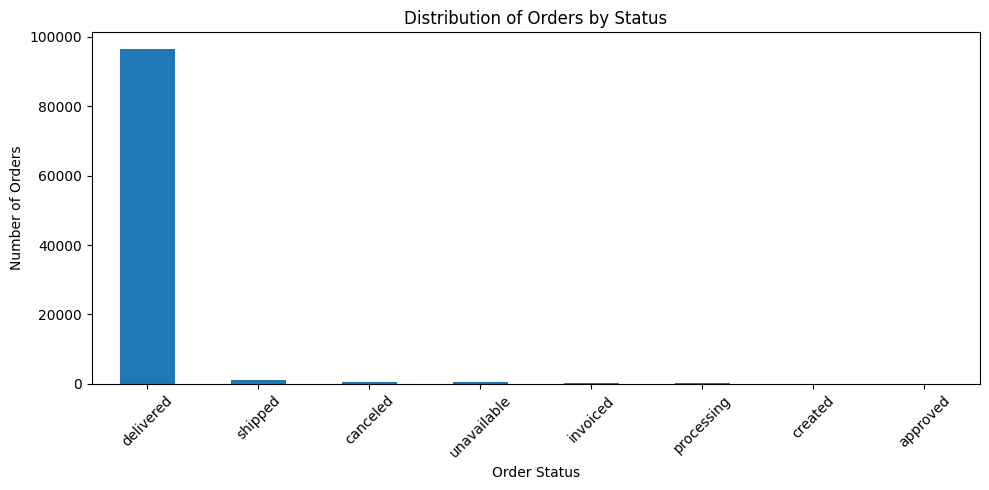

In [30]:
plt.figure(figsize=(10, 5))

order_status_counts.plot(kind="bar")

plt.title("Distribution of Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
print(order_features["order_total_value"].describe())

count    99441.000000
mean       159.326166
std        220.058804
min          0.000000
25%         61.050000
50%        104.560000
75%        176.000000
max      13664.080000
Name: order_total_value, dtype: float64


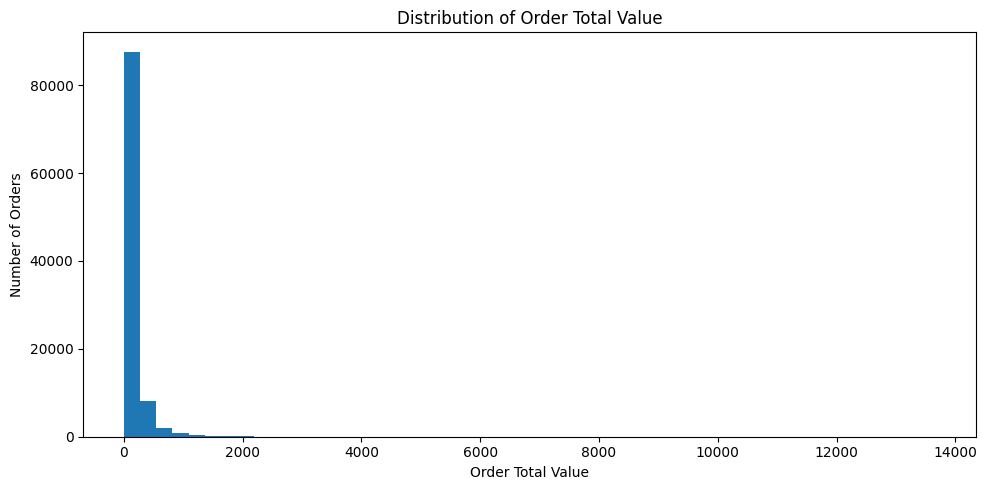

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    order_features["order_total_value"].dropna(),
    bins=50
)

plt.title("Distribution of Order Total Value")
plt.xlabel("Order Total Value")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

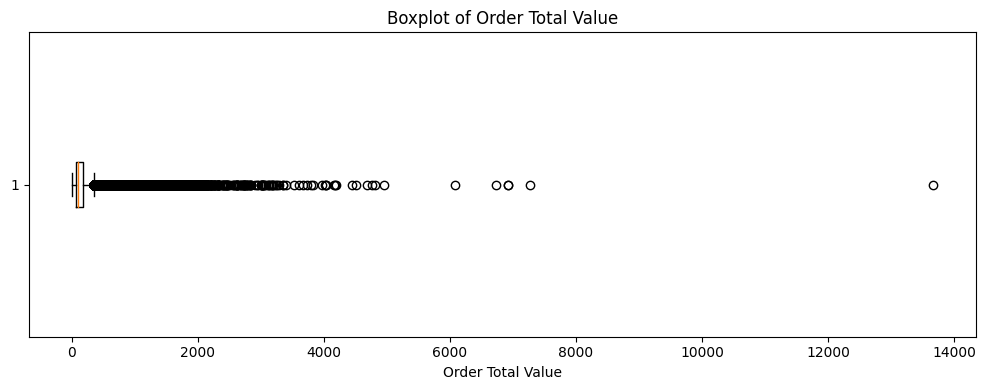

In [33]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    order_features["order_total_value"].dropna(),
    vert=False
)

plt.title("Boxplot of Order Total Value")
plt.xlabel("Order Total Value")
plt.tight_layout()
plt.show()

In [34]:
print(order_features["delivery_days"].describe())

count    96453.000000
mean        12.095435
std          9.552181
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


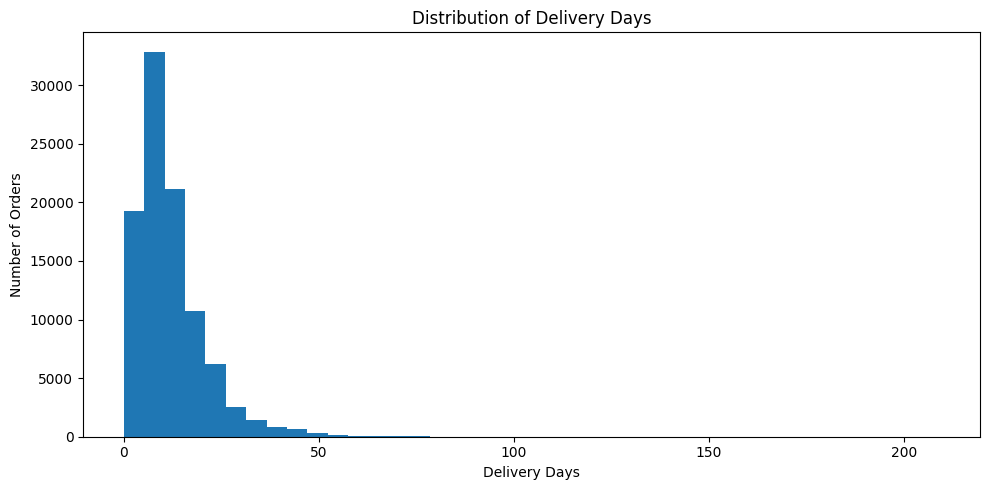

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(
    order_features["delivery_days"].dropna(),
    bins=40
)

plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [36]:
print(order_features["delivery_delay_days"].describe())

count    96453.000000
mean       -11.873876
std         10.181480
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


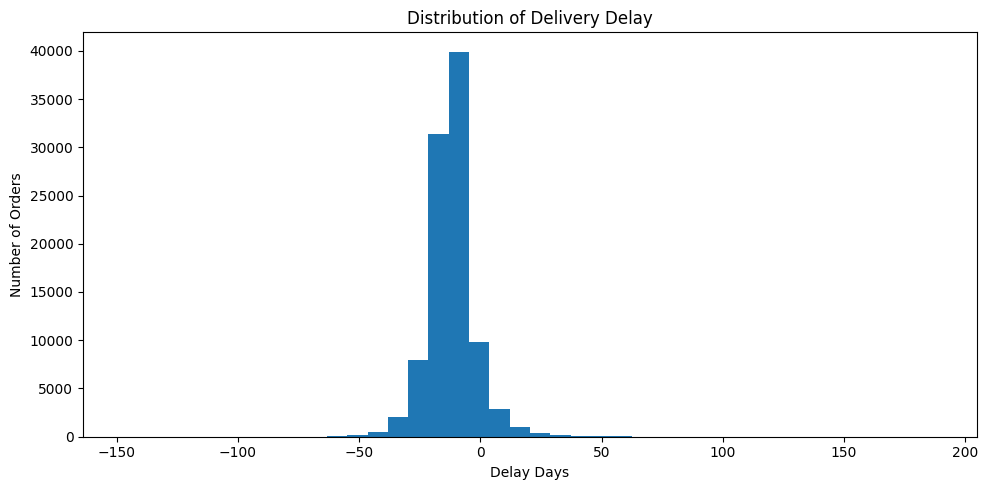

In [37]:
plt.figure(figsize=(10, 5))

plt.hist(
    order_features["delivery_delay_days"].dropna(),
    bins=40
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delay Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [38]:
delivery_status_counts = (
    order_features["delivery_status"]
    .value_counts()
)

display(delivery_status_counts)

Early            88626
Late              6535
Not Delivered     2988
On Time           1292
Name: delivery_status, dtype: int64

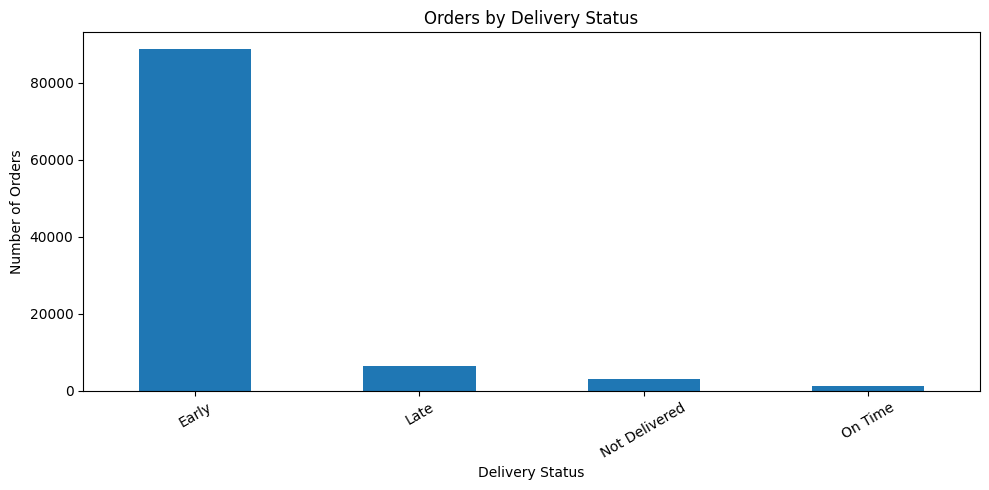

In [39]:
plt.figure(figsize=(10, 5))

delivery_status_counts.plot(kind="bar")

plt.title("Orders by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [40]:
print(customer_features["customer_order_count"].describe())

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: customer_order_count, dtype: float64


In [41]:
repeat_counts = (
    customer_features["repeat_customer_indicator"]
    .value_counts()
)

display(repeat_counts)

0    93099
1     2997
Name: repeat_customer_indicator, dtype: int64

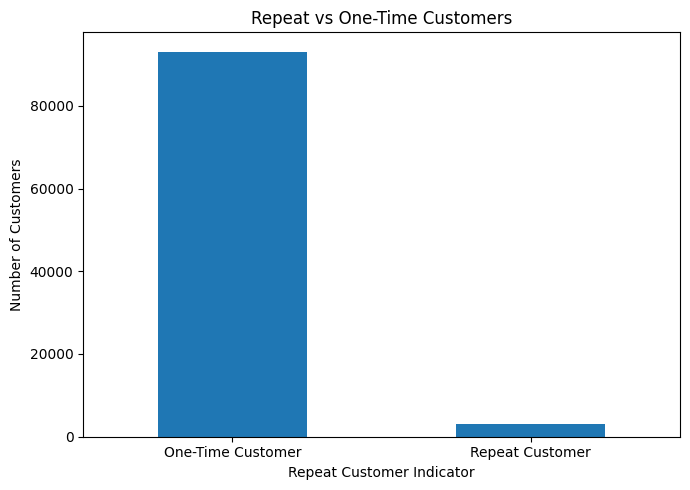

In [42]:
plt.figure(figsize=(7, 5))

repeat_counts.plot(
    kind="bar"
)

plt.title("Repeat vs One-Time Customers")
plt.xlabel("Repeat Customer Indicator")
plt.ylabel("Number of Customers")
plt.xticks(
    [0, 1],
    ["One-Time Customer", "Repeat Customer"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [43]:
print(
    customer_features[
        "customer_total_spending"
    ].describe()
)

count    96096.000000
mean       164.872141
std        227.938658
min          0.000000
25%         62.390000
50%        107.270000
75%        182.237500
max      13664.080000
Name: customer_total_spending, dtype: float64


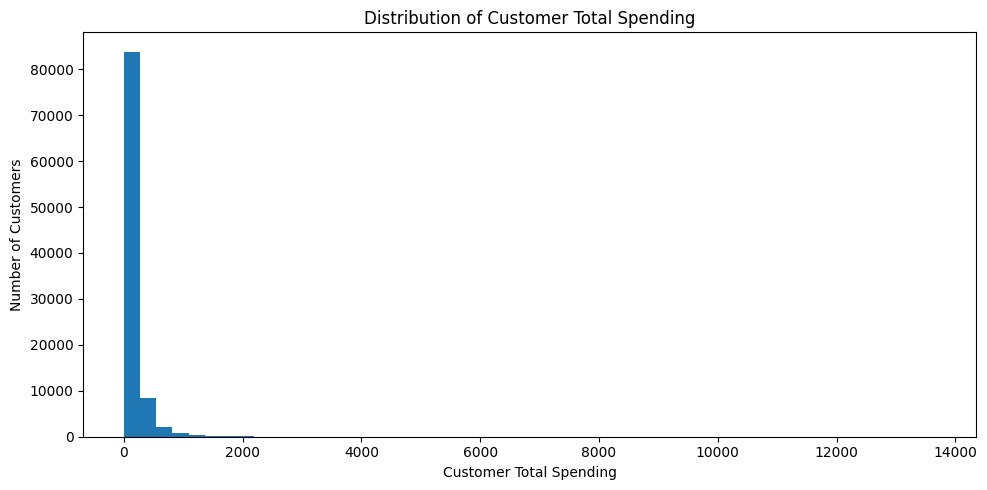

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_features[
        "customer_total_spending"
    ].dropna(),
    bins=50
)

plt.title("Distribution of Customer Total Spending")
plt.xlabel("Customer Total Spending")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [45]:
print(
    customer_features[
        "average_order_value"
    ].describe()
)

count    96096.000000
mean       159.810249
std        220.564406
min          0.000000
25%         61.690000
50%        105.180000
75%        176.230000
max      13664.080000
Name: average_order_value, dtype: float64


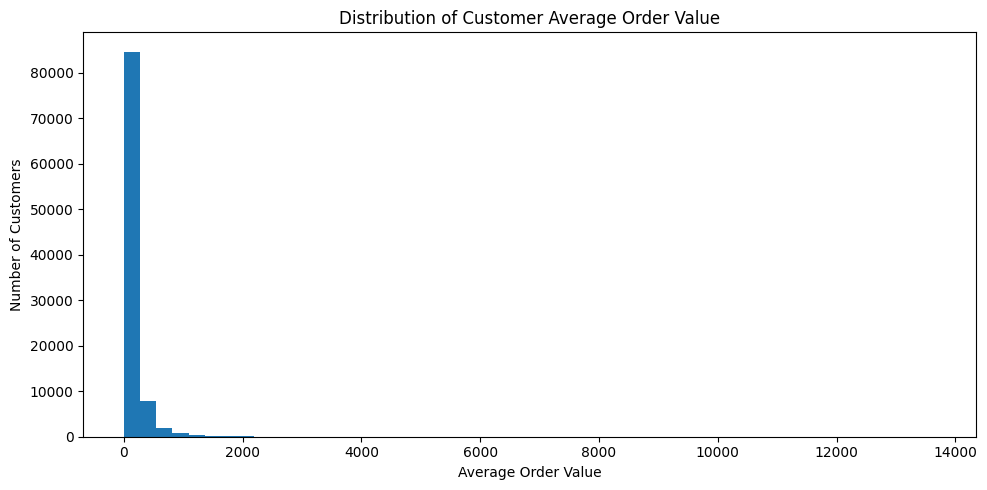

In [46]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_features[
        "average_order_value"
    ].dropna(),
    bins=50
)

plt.title("Distribution of Customer Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [47]:
top_sellers_revenue = (
    seller_features
    .sort_values(
        "seller_revenue",
        ascending=False
    )
    .head(10)
)

display(
    top_sellers_revenue[
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "seller_revenue",
            "seller_order_count",
            "items_sold"
        ]
    ]
)

,seller_id,seller_city,seller_state,seller_revenue,seller_order_count,items_sold
857,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,229472.63,1132,1156
1013,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,222776.05,358,410
881,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,200472.92,1806,1987
3024,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,194042.03,585,586
1535,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,187923.89,982,1364
1560,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,176431.87,336,340
2643,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,160236.57,1314,1551
1505,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,141745.53,1160,1171
192,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,138968.55,915,1428
1824,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,135171.70,1287,1499


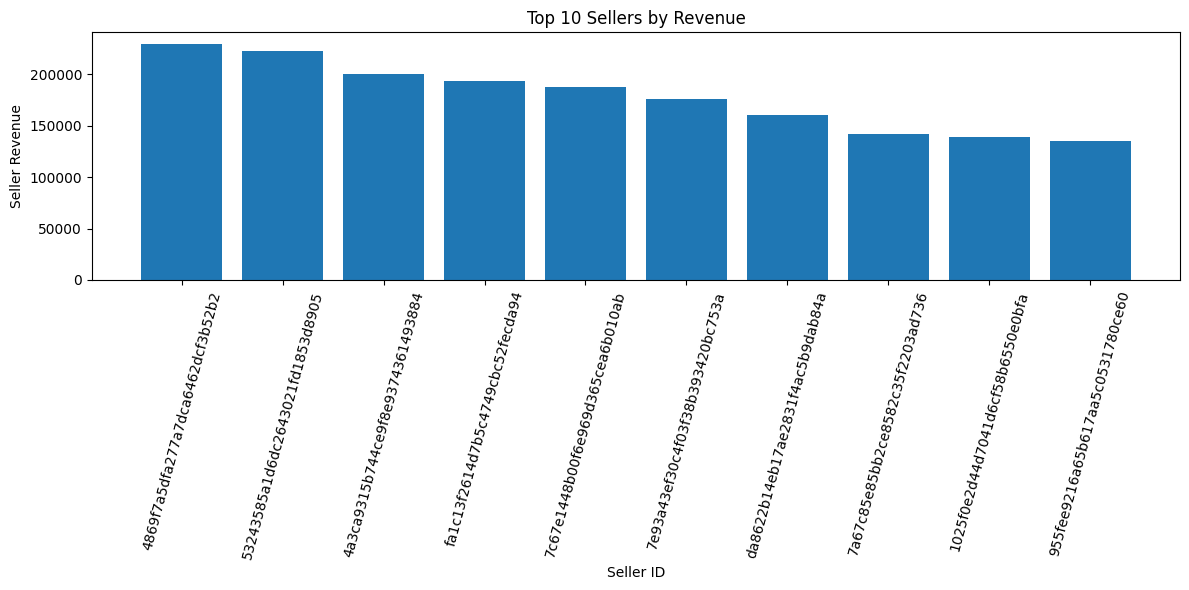

In [48]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_sellers_revenue["seller_id"].astype(str),
    top_sellers_revenue["seller_revenue"]
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Seller Revenue")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [49]:
top_products = (
    product_features
    .sort_values(
        "product_revenue",
        ascending=False
    )
    .head(10)
)

display(
    top_products[
        [
            "product_id",
            "category_english",
            "items_sold",
            "order_count",
            "product_revenue"
        ]
    ]
)

,product_id,category_english,items_sold,order_count,product_revenue
24086,bb50f2e236e5eea0100680137654686c,health_beauty,195,187,63885.00
14068,6cdd53843498f92890544667809f1595,health_beauty,156,151,54730.20
27613,d6160fb7873f184099d9bc95e30376af,computers,35,35,48899.34
27039,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,343,323,47214.51
19742,99a4788cb24856965c36a24e339b6058,bed_bath_table,488,467,43025.56
8051,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,274,255,41082.60
4996,25c38557cf793876c5abdd5931f922db,baby,38,38,38907.32
12351,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,63,63,37733.90
10867,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,323,306,37683.42
22112,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,527,431,37608.90


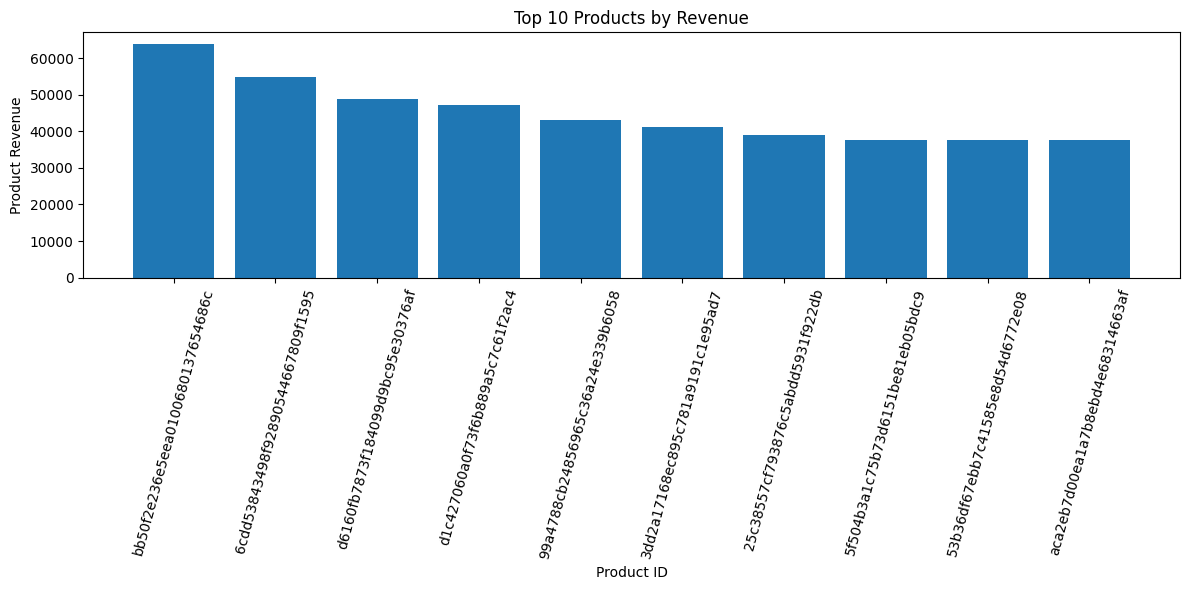

In [50]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_products["product_id"].astype(str),
    top_products["product_revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Product Revenue")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [51]:
top_categories = (
    category_features
    .sort_values(
        "category_revenue",
        ascending=False
    )
    .head(10)
)

display(top_categories)

,category_name,product_count,items_sold,order_count,category_revenue,category_freight_value
43,health_beauty,2444,9670,8836,1258681.34,182566.73
73,watches_gifts,1329,5991,5624,1205005.68,100535.93
7,bed_bath_table,3029,11115,9417,1036988.68,204693.04
67,sports_leisure,2867,8641,7720,988048.97,168607.51
15,computers_accessories,1639,7827,6689,911954.32,147318.08
39,furniture_decor,2657,8334,6449,729762.49,172749.30
20,cool_stuff,789,3796,3632,635290.85,84039.10
49,housewares,2335,6964,5884,632248.66,146149.11
5,auto,1900,4235,3897,592720.11,92664.21
42,garden_tools,753,4347,3518,485256.46,98962.75


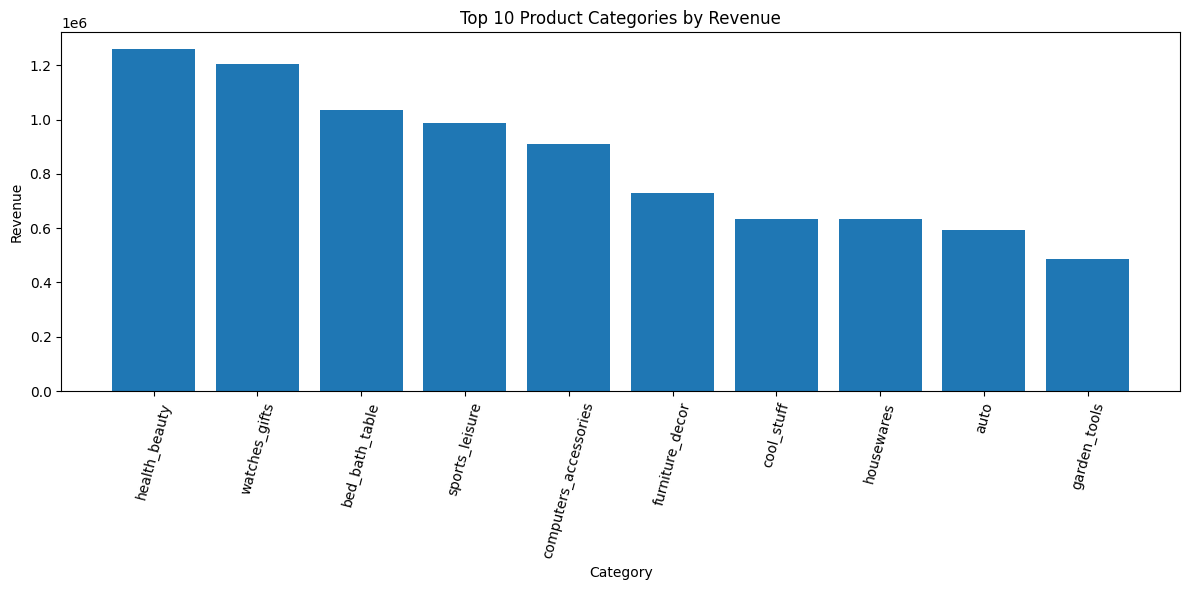

In [52]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_categories["category_name"],
    top_categories["category_revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

BIVARIATE ANALYSIS

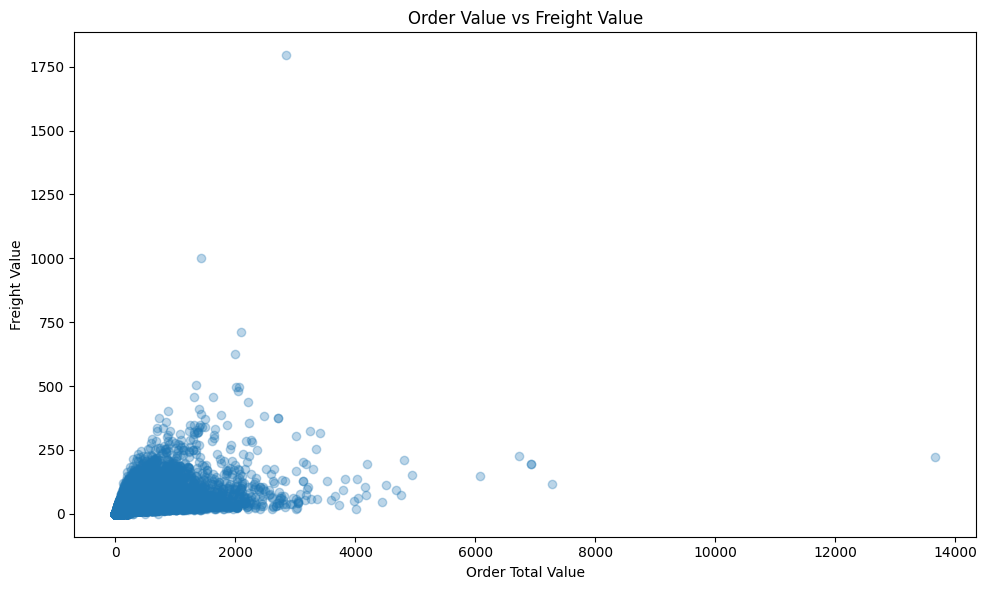

In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(
    order_features["order_total_value"],
    order_features["freight_total"],
    alpha=0.3
)

plt.title("Order Value vs Freight Value")
plt.xlabel("Order Total Value")
plt.ylabel("Freight Value")
plt.tight_layout()
plt.show()

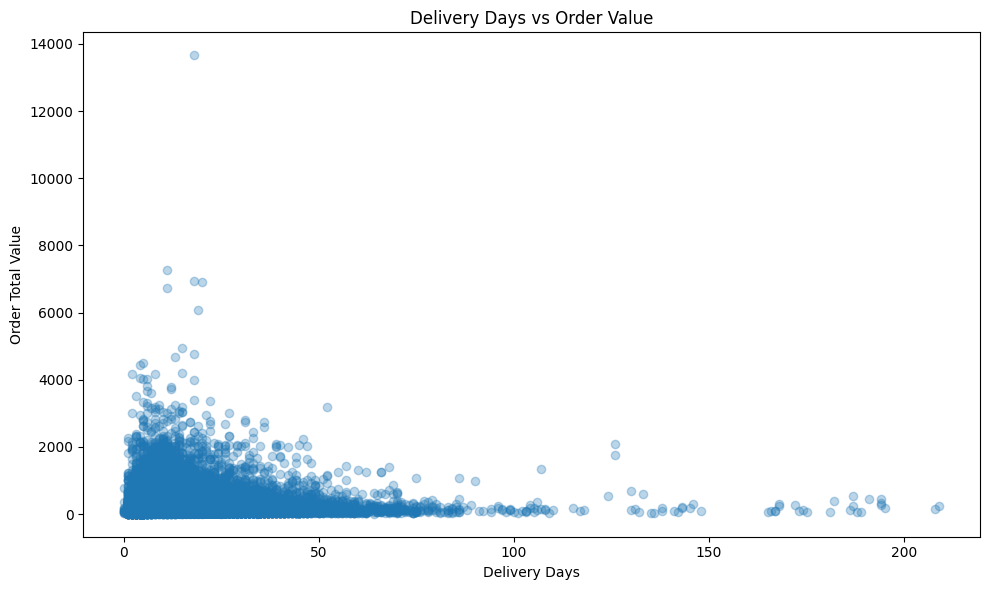

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(
    order_features["delivery_days"],
    order_features["order_total_value"],
    alpha=0.3
)

plt.title("Delivery Days vs Order Value")
plt.xlabel("Delivery Days")
plt.ylabel("Order Total Value")
plt.tight_layout()
plt.show()

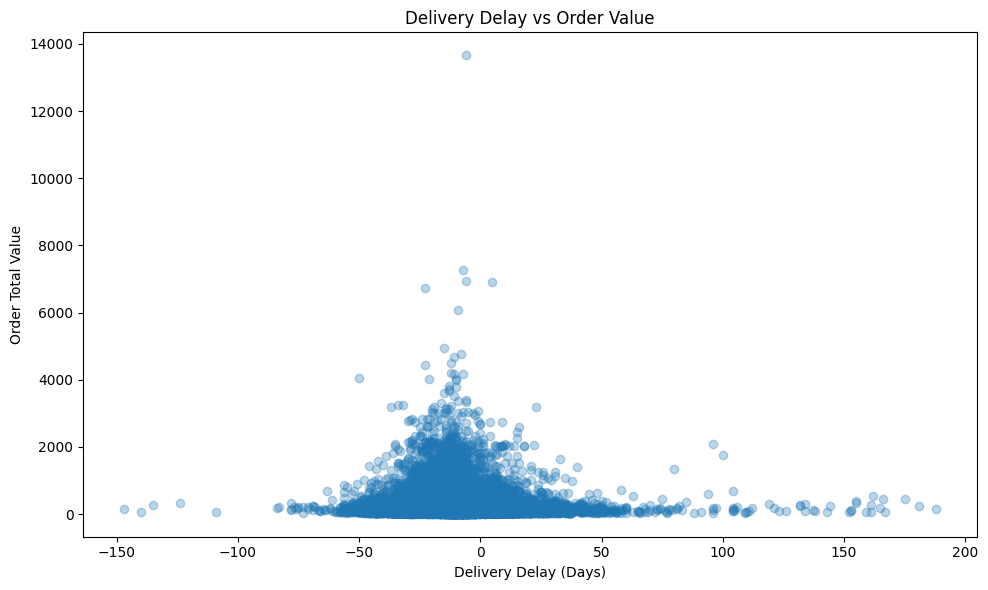

In [55]:
plt.figure(figsize=(10, 6))

plt.scatter(
    order_features["delivery_delay_days"],
    order_features["order_total_value"],
    alpha=0.3
)

plt.title("Delivery Delay vs Order Value")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Order Total Value")
plt.tight_layout()
plt.show()

In [56]:
order_features["order_month"] = (
    order_features["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_sales = (
    order_features
    .groupby("order_month")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("order_total_value", "sum"),
        average_order_value=("order_total_value", "mean")
    )
    .reset_index()
)

display(monthly_sales.head())

,order_month,total_orders,total_revenue,average_order_value
0,2016-09,4,354.75,88.687500
1,2016-10,324,56808.84,175.335926
2,2016-12,1,19.62,19.620000
3,2017-01,800,137188.49,171.485613
4,2017-02,1780,286280.62,160.831809


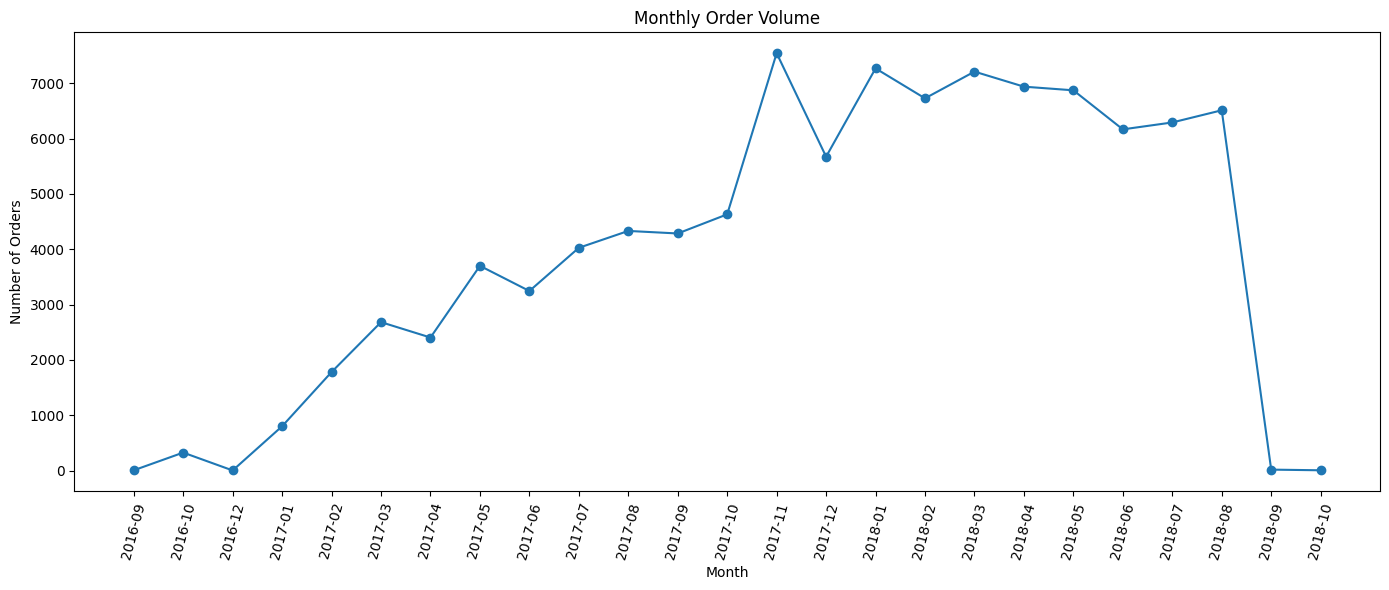

In [57]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["order_month"],
    monthly_sales["total_orders"],
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

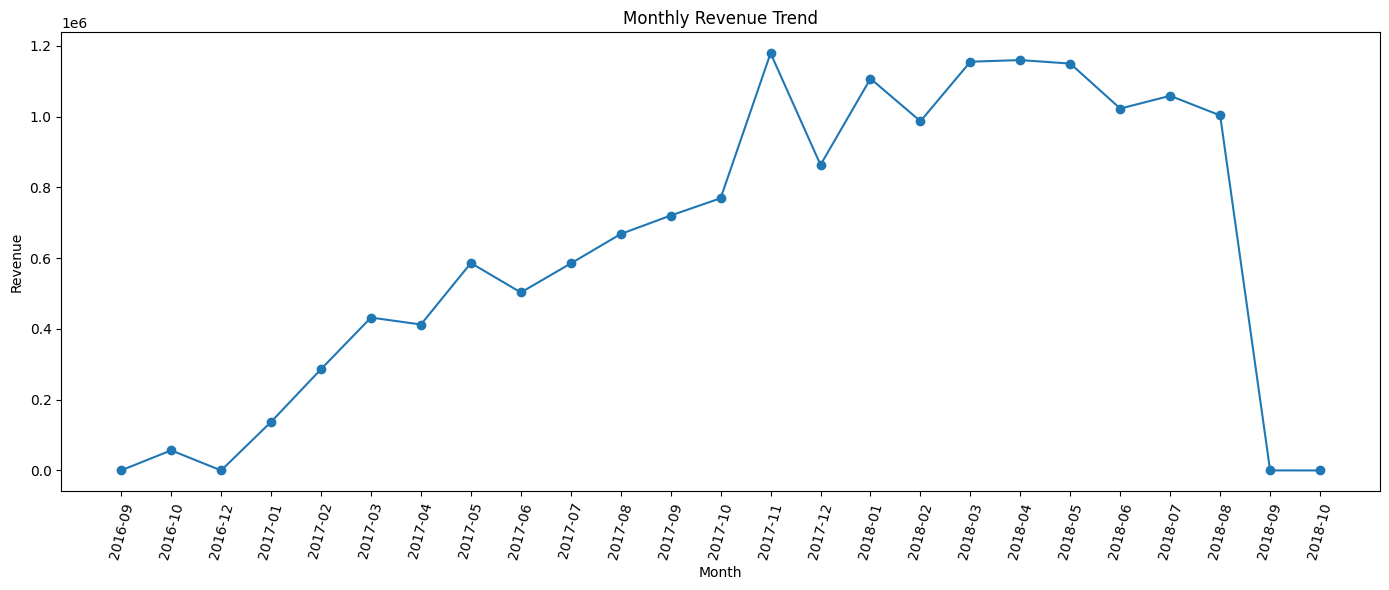

In [58]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["order_month"],
    monthly_sales["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

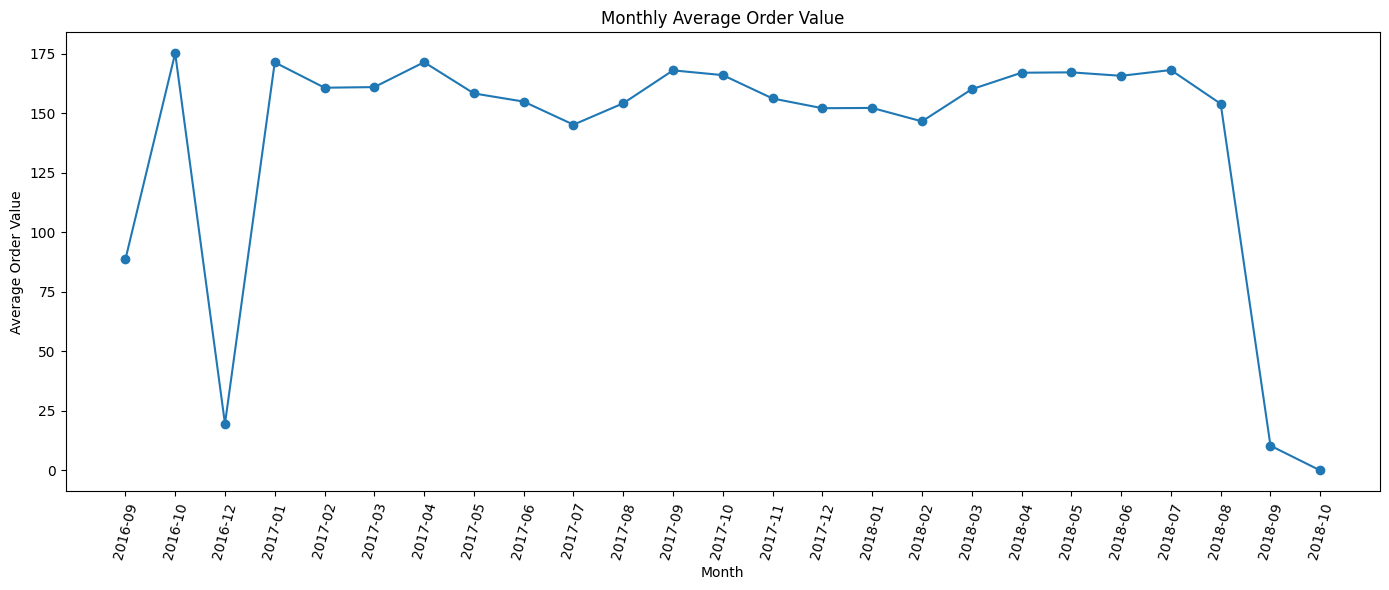

In [59]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["order_month"],
    monthly_sales["average_order_value"],
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [60]:
order_features["order_day"] = (
    order_features["order_purchase_timestamp"]
    .dt.day_name()
)

day_order_counts = (
    order_features["order_day"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

display(day_order_counts)

Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: order_day, dtype: int64

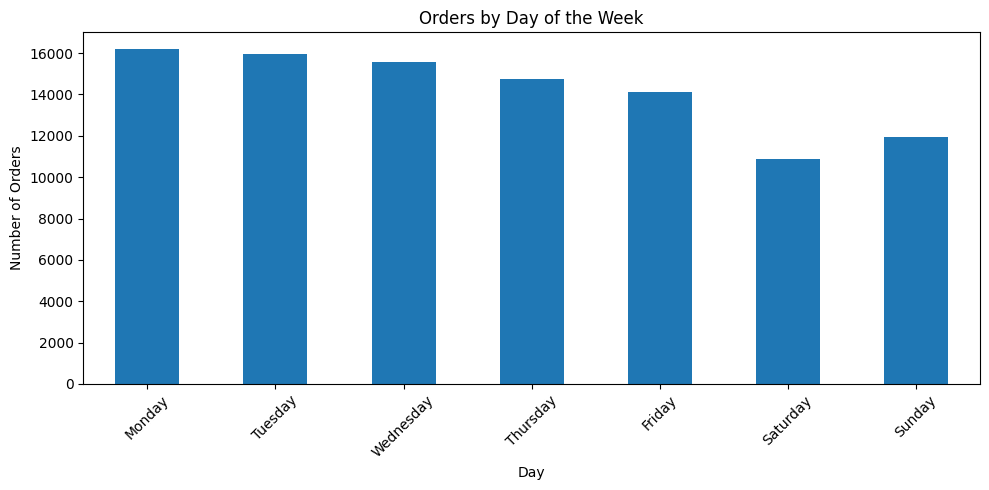

In [61]:
plt.figure(figsize=(10, 5))

day_order_counts.plot(kind="bar")

plt.title("Orders by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [62]:
delivery_summary = (
    order_features
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "nunique"),
        average_delivery_days=("delivery_days", "mean"),
        average_delay_days=("delivery_delay_days", "mean")
    )
    .reset_index()
)

display(delivery_summary)

,delivery_status,orders,average_delivery_days,average_delay_days
0,Early,88626,10.420779,-13.705628
1,Late,6535,33.487529,10.620352
2,Not Delivered,2988,NaN,NaN
3,On Time,1292,18.767802,0.000000


In [63]:
monthly_delivery = (
    order_features
    .dropna(subset=["delivery_delay_days"])
    .groupby("order_month")
    .agg(
        average_delay_days=("delivery_delay_days", "mean"),
        average_delivery_days=("delivery_days", "mean")
    )
    .reset_index()
)

display(monthly_delivery.head())

,order_month,average_delay_days,average_delivery_days
0,2016-09,36.000000,54.000000
1,2016-10,-36.616541,19.187970
2,2016-12,-22.000000,4.000000
3,2017-01,-27.363151,12.084112
4,2017-02,-19.189582,12.615990


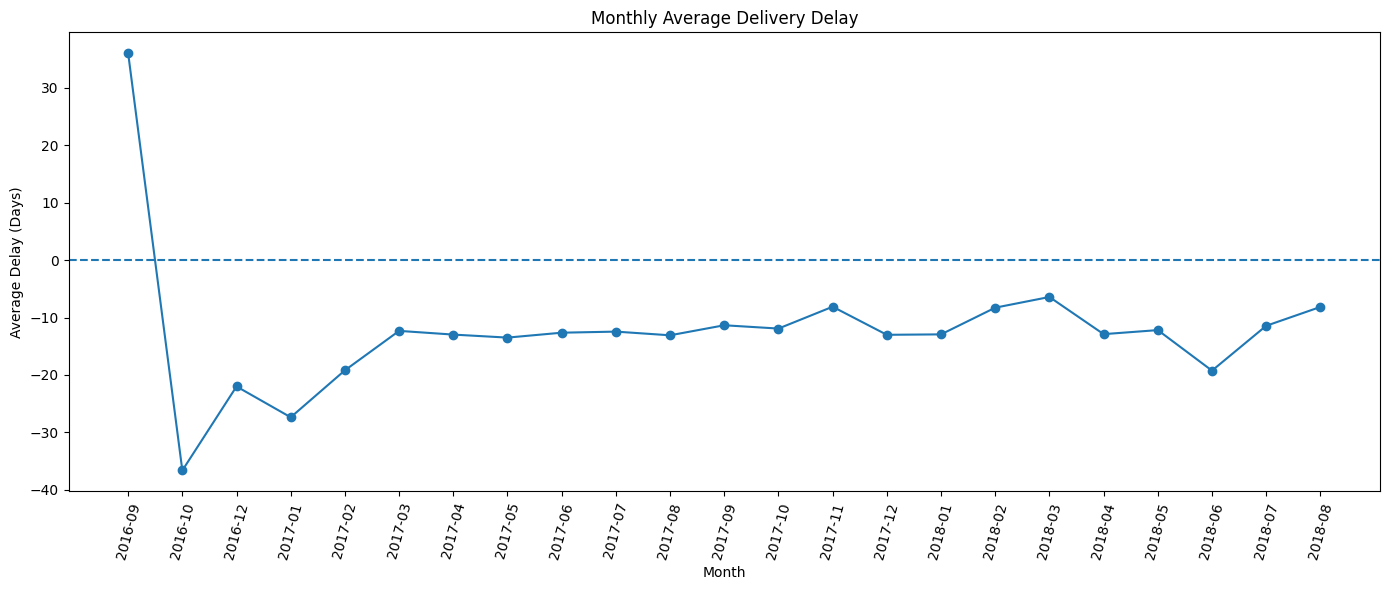

In [64]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_delivery["order_month"],
    monthly_delivery["average_delay_days"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Monthly Average Delivery Delay")
plt.xlabel("Month")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [65]:
freight_summary = order_features[
    [
        "order_total_value",
        "freight_total"
    ]
].describe()

display(freight_summary)

,order_total_value,freight_total
count,99441.000000,99441.000000
mean,159.326166,22.645685
std,220.058804,21.659564
min,0.000000,0.000000
25%,61.050000,13.720000
50%,104.560000,17.090000
75%,176.000000,23.920000
max,13664.080000,1794.960000


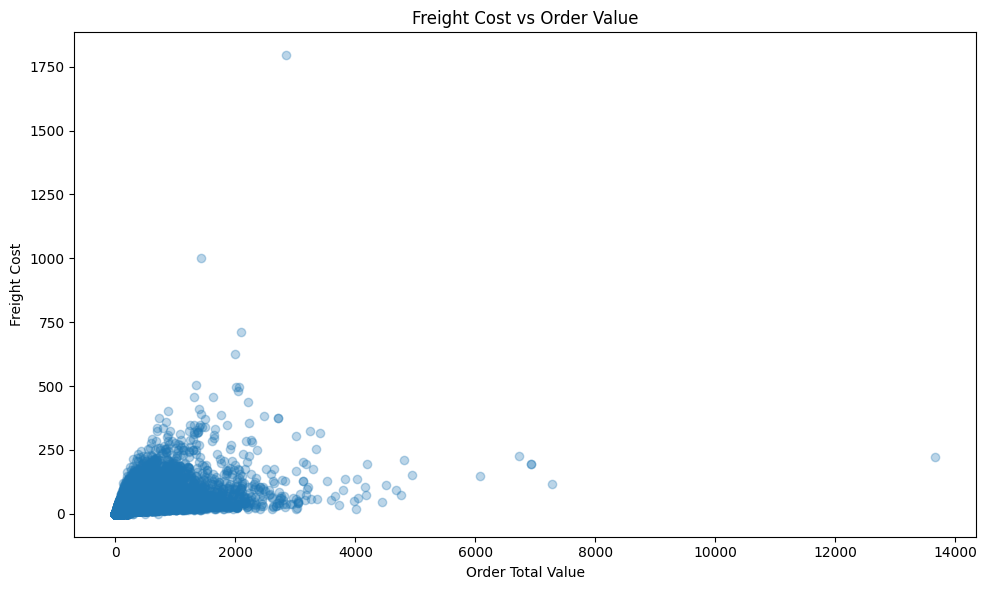

In [66]:
plt.figure(figsize=(10, 6))

plt.scatter(
    order_features["order_total_value"],
    order_features["freight_total"],
    alpha=0.3
)

plt.title("Freight Cost vs Order Value")
plt.xlabel("Order Total Value")
plt.ylabel("Freight Cost")
plt.tight_layout()
plt.show()

MULTIVARIATE ANALYSIS

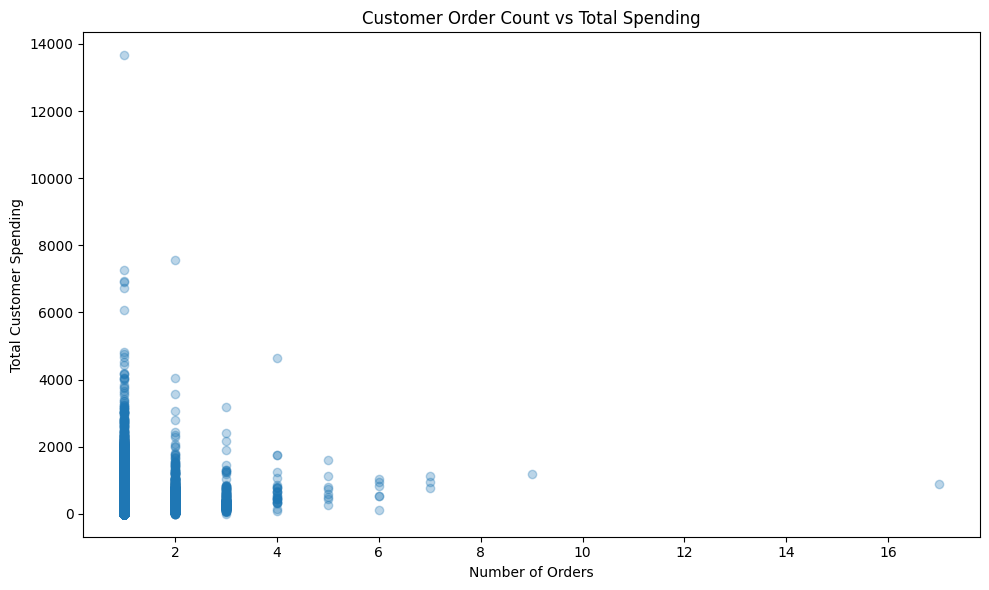

In [67]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_features["customer_order_count"],
    customer_features["customer_total_spending"],
    alpha=0.3
)

plt.title(
    "Customer Order Count vs Total Spending"
)

plt.xlabel("Number of Orders")
plt.ylabel("Total Customer Spending")

plt.tight_layout()
plt.show()

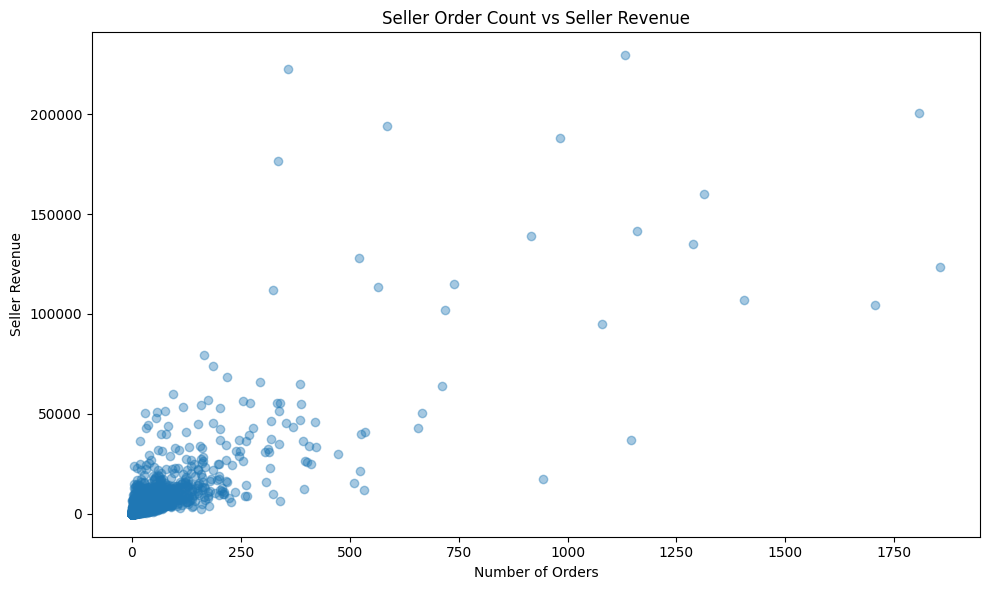

In [68]:
plt.figure(figsize=(10, 6))

plt.scatter(
    seller_features["seller_order_count"],
    seller_features["seller_revenue"],
    alpha=0.4
)

plt.title("Seller Order Count vs Seller Revenue")
plt.xlabel("Number of Orders")
plt.ylabel("Seller Revenue")

plt.tight_layout()
plt.show()

In [69]:
order_numeric = order_features[
    [
        "item_price_total",
        "freight_total",
        "order_total_value",
        "delivery_days",
        "delivery_delay_days",
        "is_delayed"
    ]
]

order_correlation = order_numeric.corr()

display(order_correlation)

,item_price_total,freight_total,order_total_value,delivery_days,delivery_delay_days,is_delayed
item_price_total,1.000000,0.415668,0.995985,0.055491,-0.013389,0.017848
freight_total,0.415668,1.000000,0.495419,0.167222,-0.049228,0.030801
order_total_value,0.995985,0.495419,1.000000,0.069494,-0.017643,0.020087
delivery_days,0.055491,0.167222,0.069494,1.000000,0.607914,0.603743
delivery_delay_days,-0.013389,-0.049228,-0.017643,0.607914,1.000000,0.595610
is_delayed,0.017848,0.030801,0.020087,0.603743,0.595610,1.000000


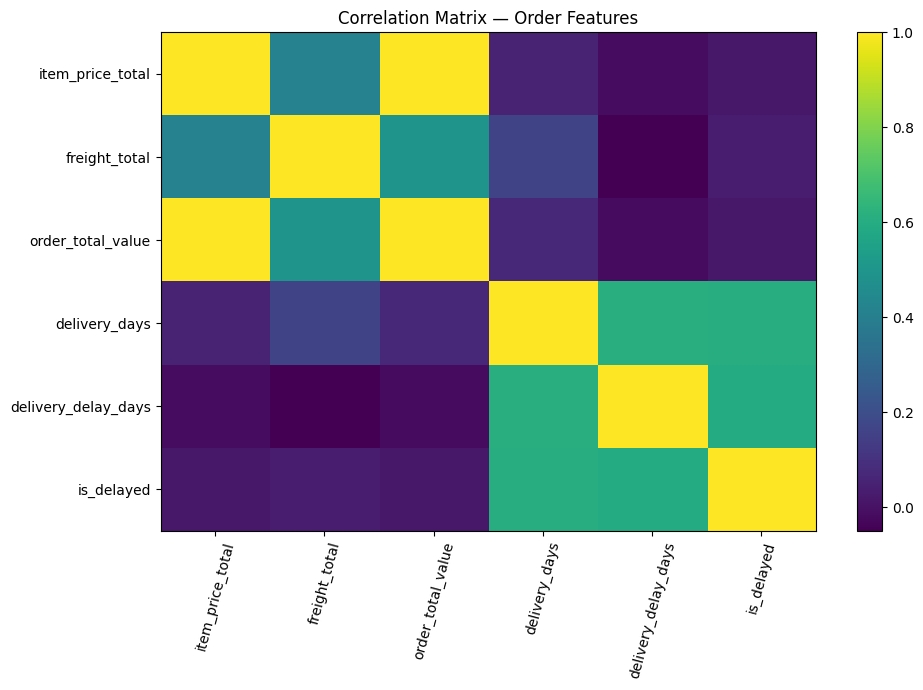

In [70]:
plt.figure(figsize=(10, 7))

plt.imshow(
    order_correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(order_correlation.columns)),
    order_correlation.columns,
    rotation=75
)

plt.yticks(
    range(len(order_correlation.columns)),
    order_correlation.columns
)

plt.title("Correlation Matrix — Order Features")

plt.tight_layout()
plt.show()

In [71]:
customer_numeric = customer_features[
    [
        "customer_order_count",
        "customer_total_spending",
        "average_order_value",
        "repeat_customer_indicator"
    ]
]

customer_correlation = customer_numeric.corr()

display(customer_correlation)

,customer_order_count,customer_total_spending,average_order_value,repeat_customer_indicator
customer_order_count,1.000000,0.122369,-0.010591,0.904962
customer_total_spending,0.122369,1.000000,0.981798,0.112391
average_order_value,-0.010591,0.981798,1.000000,-0.011763
repeat_customer_indicator,0.904962,0.112391,-0.011763,1.000000


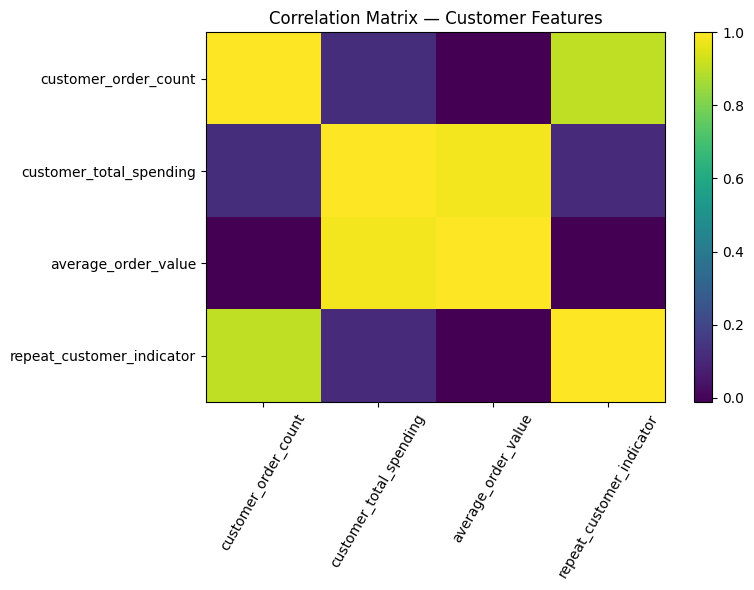

In [72]:
plt.figure(figsize=(8, 6))

plt.imshow(
    customer_correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(customer_correlation.columns)),
    customer_correlation.columns,
    rotation=60
)

plt.yticks(
    range(len(customer_correlation.columns)),
    customer_correlation.columns
)

plt.title("Correlation Matrix — Customer Features")

plt.tight_layout()
plt.show()

In [73]:
category_performance = (
    category_features
    .sort_values(
        "category_revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    category_performance.head(15)
)

,category_name,product_count,items_sold,order_count,category_revenue,category_freight_value
0,health_beauty,2444,9670,8836,1258681.34,182566.73
1,watches_gifts,1329,5991,5624,1205005.68,100535.93
2,bed_bath_table,3029,11115,9417,1036988.68,204693.04
3,sports_leisure,2867,8641,7720,988048.97,168607.51
4,computers_accessories,1639,7827,6689,911954.32,147318.08
5,furniture_decor,2657,8334,6449,729762.49,172749.30
6,cool_stuff,789,3796,3632,635290.85,84039.10
7,housewares,2335,6964,5884,632248.66,146149.11
8,auto,1900,4235,3897,592720.11,92664.21
9,garden_tools,753,4347,3518,485256.46,98962.75


In [74]:
top_sellers_orders = (
    seller_features
    .sort_values(
        "seller_order_count",
        ascending=False
    )
    .head(10)
)

display(
    top_sellers_orders[
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "seller_order_count",
            "seller_revenue",
            "items_sold"
        ]
    ]
)

,seller_id,seller_city,seller_state,seller_order_count,seller_revenue,items_sold
1235,6560211a19b47992c3666cc44a7e94c0,sao paulo,SP,1854,123304.83,2033
881,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1806,200472.92,1987
2481,cc419e0650a3c5ba77189a1882b7556a,santo andre,SP,1706,104288.42,1775
368,1f50f920176fa81dab994f9023523100,sao jose do rio preto,SP,1404,106939.21,1931
2643,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,1314,160236.57,1551
1824,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,1287,135171.70,1499
1505,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,1160,141745.53,1171
2836,ea8482cd71df3c1969d7b9473ff13abc,sao paulo,SP,1146,37177.52,1203
857,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1132,229472.63,1156
731,3d871de0142ce09b7081e2b9d1733cb1,campo limpo paulista,SP,1080,94914.20,1147


In [75]:
top_products_units = (
    product_features
    .sort_values(
        "items_sold",
        ascending=False
    )
    .head(10)
)

display(
    top_products_units[
        [
            "product_id",
            "category_english",
            "items_sold",
            "order_count",
            "product_revenue"
        ]
    ]
)

,product_id,category_english,items_sold,order_count,product_revenue
22112,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,527,431,37608.90
19742,99a4788cb24856965c36a24e339b6058,bed_bath_table,488,467,43025.56
8613,422879e10f46682990de24d770e7f83d,garden_tools,484,352,26577.22
7364,389d119b48cf3043d311335e499d9c6b,garden_tools,392,311,21440.59
7079,368c6c730842d78016ad823897a372db,garden_tools,388,291,21056.80
10840,53759a2ecddad2bb87a079a1f1519f73,garden_tools,373,287,20387.20
27039,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,343,323,47214.51
10867,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,323,306,37683.42
2794,154e7e31ebfa092203795c972e5804a6,health_beauty,281,269,6325.19
8051,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,274,255,41082.60


In [76]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Revenue",
        "Average Order Value",
        "Median Order Value",
        "Total Freight"
    ],
    "Value": [
        order_features["order_id"].nunique(),
        order_features["order_total_value"].sum(),
        order_features["order_total_value"].mean(),
        order_features["order_total_value"].median(),
        order_features["freight_total"].sum()
    ]
})

display(sales_summary)

,Metric,Value
0,Total Orders,9.944100e+04
1,Total Revenue,1.584355e+07
2,Average Order Value,1.593262e+02
3,Median Order Value,1.045600e+02
4,Total Freight,2.251910e+06


In [77]:
customer_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Repeat Customers",
        "One-Time Customers",
        "Average Customer Spending",
        "Average Customer Order Count"
    ],
    "Value": [
        customer_features["customer_unique_id"].nunique(),
        (
            customer_features["repeat_customer_indicator"] == 1
        ).sum(),
        (
            customer_features["repeat_customer_indicator"] == 0
        ).sum(),
        customer_features["customer_total_spending"].mean(),
        customer_features["customer_order_count"].mean()
    ]
})

display(customer_summary)

,Metric,Value
0,Total Customers,96096.000000
1,Repeat Customers,2997.000000
2,One-Time Customers,93099.000000
3,Average Customer Spending,164.872141
4,Average Customer Order Count,1.034809


In [78]:
delivery_summary_overall = pd.DataFrame({
    "Metric": [
        "Delivered Orders",
        "Late Orders",
        "On-Time Orders",
        "Early Orders",
        "Average Delivery Days",
        "Average Delivery Delay"
    ],
    "Value": [
        (
            order_features["delivery_status"]
            .isin(["Late", "On Time", "Early"])
        ).sum(),
        (
            order_features["delivery_status"] == "Late"
        ).sum(),
        (
            order_features["delivery_status"] == "On Time"
        ).sum(),
        (
            order_features["delivery_status"] == "Early"
        ).sum(),
        order_features["delivery_days"].mean(),
        order_features["delivery_delay_days"].mean()
    ]
})

display(delivery_summary_overall)

,Metric,Value
0,Delivered Orders,96453.000000
1,Late Orders,6535.000000
2,On-Time Orders,1292.000000
3,Early Orders,88626.000000
4,Average Delivery Days,12.095435
5,Average Delivery Delay,-11.873876


In [79]:
import os

eda_output_path = "../data/eda_outputs"

os.makedirs(
    eda_output_path,
    exist_ok=True
)

print(
    "EDA output folder created:",
    eda_output_path
)

EDA output folder created: ../data/eda_outputs


In [80]:
sales_summary.to_csv(
    f"{eda_output_path}/sales_summary.csv",
    index=False
)

customer_summary.to_csv(
    f"{eda_output_path}/customer_summary.csv",
    index=False
)

delivery_summary_overall.to_csv(
    f"{eda_output_path}/delivery_summary.csv",
    index=False
)

monthly_sales.to_csv(
    f"{eda_output_path}/monthly_sales.csv",
    index=False
)

monthly_delivery.to_csv(
    f"{eda_output_path}/monthly_delivery.csv",
    index=False
)

category_performance.to_csv(
    f"{eda_output_path}/category_performance.csv",
    index=False
)

top_sellers_revenue.to_csv(
    f"{eda_output_path}/top_sellers_revenue.csv",
    index=False
)

top_products.to_csv(
    f"{eda_output_path}/top_products_revenue.csv",
    index=False
)

print("EDA summary files saved successfully.")

EDA summary files saved successfully.


In [81]:
order_correlation.to_csv(
    f"{eda_output_path}/order_correlation.csv"
)

customer_correlation.to_csv(
    f"{eda_output_path}/customer_correlation.csv"
)

print("Correlation matrices saved successfully.")

Correlation matrices saved successfully.


In [82]:
print("========== STEP 8 EDA VALIDATION ==========")

print("\nDatasets loaded:")
print("✓ order_features")
print("✓ customer_features")
print("✓ seller_features")
print("✓ product_features")
print("✓ category_features")
print("✓ order_enriched_features")

print("\nEDA analyses completed:")
print("✓ Dataset understanding")
print("✓ Missing-value analysis")
print("✓ Duplicate analysis")
print("✓ Univariate analysis")
print("✓ Bivariate analysis")
print("✓ Multivariate analysis")
print("✓ Sales trend analysis")
print("✓ Customer analysis")
print("✓ Seller analysis")
print("✓ Product analysis")
print("✓ Category analysis")
print("✓ Delivery analysis")
print("✓ Freight analysis")
print("✓ Correlation analysis")

print("\nEDA output files created:")
print("✓ Sales summary")
print("✓ Customer summary")
print("✓ Delivery summary")
print("✓ Monthly sales")
print("✓ Monthly delivery")
print("✓ Category performance")
print("✓ Top sellers")
print("✓ Top products")
print("✓ Correlation matrices")

print("\nSTEP 8 EDA COMPLETED SUCCESSFULLY.")

========== STEP 8 EDA VALIDATION ==========

Datasets loaded:
✓ order_features
✓ customer_features
✓ seller_features
✓ product_features
✓ category_features
✓ order_enriched_features

EDA analyses completed:
✓ Dataset understanding
✓ Missing-value analysis
✓ Duplicate analysis
✓ Univariate analysis
✓ Bivariate analysis
✓ Multivariate analysis
✓ Sales trend analysis
✓ Customer analysis
✓ Seller analysis
✓ Product analysis
✓ Category analysis
✓ Delivery analysis
✓ Freight analysis
✓ Correlation analysis

EDA output files created:
✓ Sales summary
✓ Customer summary
✓ Delivery summary
✓ Monthly sales
✓ Monthly delivery
✓ Category performance
✓ Top sellers
✓ Top products
✓ Correlation matrices

STEP 8 EDA COMPLETED SUCCESSFULLY.
